# Experiment 3: Neural Network with Just 10 Linear Layers Stacked

<p>
Andrej said that if we have 10 different linear layers stacked on top of one another then they collapse and behave like ONE linear layer in a neural network. 
Let's try that now. 
</p>

## Phase 0: Global Initilizers and Setup

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
words = open("names.txt", "r").read().splitlines()
print(f'Total Names: {len(words)}')
print(f'First 8 names: {words[:8]}')

Total Names: 32033
First 8 names: ['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']


In [3]:
chars = sorted(list(set("".join(words))))
stoi = {s:i+1 for i, s in enumerate(chars)}
stoi["."]=0
itos={i:s for s, i in stoi.items()}
vocab_size = len(itos)
print(f'Indexes to string dict: {itos}')
print(f'Len of Indexes to string dictionary (i.e Vocabulary size): {vocab_size}')

Indexes to string dict: {1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
Len of Indexes to string dictionary (i.e Vocabulary size): 27


In [4]:
block_size = 3
def build_dataset(words):
    X, Y = [], []
    for word in words:
        context = [0]*block_size
        for char in word + ".":
            ix = stoi[char]
            X.append(context)
            Y.append(ix)
            context = context[1:]+[ix]
    X= torch.tensor(X)
    Y= torch.tensor(Y)
    print(f'X-Shape:{X.shape}, Y-shape:{Y.shape}')
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1=int(0.8*len(words))
n2=int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1]) #80%
Xdev, Ydev = build_dataset(words[n1:n2]) #10%
Xte, Yte = build_dataset(words[n2:]) #10%


X-Shape:torch.Size([182625, 3]), Y-shape:torch.Size([182625])
X-Shape:torch.Size([22655, 3]), Y-shape:torch.Size([22655])
X-Shape:torch.Size([22866, 3]), Y-shape:torch.Size([22866])


In [5]:
class Linear:
    def __init__(self, fan_in, fan_out, bias=True, generator=None):
        self.generator = generator if generator is not None else torch.Generator().manual_seed(2147483647)
        self.weight = torch.randn(fan_in, fan_out, generator=self.generator) / fan_in**0.5
        self.bias = torch.zeros(fan_out) if bias else None

    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out
    
    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])
    
class BatchNorm1d:
    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True

        # Parameters trained with backprop
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)

        # Buffers - Trained with a running momentum
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)

    def __call__(self, x):
        # Calculate the forward pass
        if self.training:
            xmean = x.mean(0, keepdim=True)
            xvar = x.var(0, keepdim=True)
        else:
            xmean = self.running_mean
            xvar = self.running_var

        xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize to unit variance
        self.out = self.gamma * xhat + self.beta

        # Update the buffers
        if self.training:
            with torch.no_grad():
                self.running_mean = (1-self.momentum)*self.running_mean + self.momentum*xmean
                self.running_var = (1-self.momentum)*self.running_var + self.momentum*xvar
        return self.out
    
    def parameters(self):
        return [self.gamma, self.beta]
    
class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out
    
    def parameters(self):
        return []

### Experimentation Specific Functions

In [6]:
def collapse_linear_stack(layers):
    W_eff = None
    b_eff = None

    for layer in layers:
        if not isinstance(layer, Linear):
            raise ValueError("Only Linear Layers Allowed")

        W = layer.weight
        b = layer.bias

        if W_eff is None:
            W_eff = W
            b_eff = b if b is not None else torch.zeros(W.shape[1])

        else:
            b_eff = b_eff @ W
            if b is not None:
                b_eff = b_eff + b
            W_eff = W_eff @ W

    return W_eff, b_eff

In [7]:
@torch.no_grad()
def split_loss(split):
    x_data, y_data = {
        "train": (Xtr, Ytr),
        "dev": (Xdev, Ydev),
        "test": (Xte, Yte)
    }[split]

    emb = C[x_data]
    x = emb.view(emb.shape[0], -1)

    for layer in layers:
        x = layer(x)

    loss = F.cross_entropy(x, y_data)
    return loss.item()

## Phase 1: 10 Linear layers Neural Network

In [8]:
n_embd = 10 
n_hidden = 100
block_size = 3
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_embd), generator=g)
layers = [
    Linear(n_embd*block_size, n_hidden),
    Linear(                   n_hidden, n_hidden), 
    Linear(                   n_hidden, n_hidden), 
    Linear(                   n_hidden, n_hidden), 
    Linear(                   n_hidden, n_hidden), 
    Linear(                   n_hidden, n_hidden),
    Linear(                   n_hidden, n_hidden),
    Linear(                   n_hidden, n_hidden),
    Linear(                   n_hidden, n_hidden),
    Linear(                   n_hidden, vocab_size)
]

with torch.no_grad():
    # last layer make less confident
    layers[-1].weight *= 0.1
    # all other layers: apply gain
    for layer in layers[:-1]:
        if isinstance(layer, Linear):
            layer.weight *= 1

parameters = [C] + [p for layer in layers for p in layer.parameters()]
num_parameters = sum(p.nelement() for p in parameters)
print(f'Num of Parameters:{num_parameters}')
for p in parameters:
    p.requires_grad=True

Num of Parameters:86897


In [11]:
max_steps = 200000
batch_size = 32
lossi = []
grad_norms = []
activation_stats = []

for i in range(max_steps):

    # Mini batch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size, ), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]

    # Forward pass
    emb = C[Xb] # Embed the characters into the vector
    x = emb.view(emb.shape[0], -1) # Concatenate the vectors

    
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, Yb)

    # Activation stats AFTER forward pass
    if i % 10000 == 0:
        step_activation_stats = []

        for li, layer in enumerate(layers):
            if isinstance(layer, Linear):
                t = layer.out.detach()

                stats = {
                    "layer": li,
                    "mean": t.mean().item(),
                    "std": t.std().item(),
                    "min": t.min().item(),
                    "max": t.max().item(),
                    "max_abs": t.abs().max().item(),
                }

                step_activation_stats.append(stats)

                print(
                    f"Layer {li}: "
                    f"mean={stats['mean']:.4f}, "
                    f"std={stats['std']:.4f}, "
                    f"min={stats['min']:.4f}, "
                    f"max={stats['max']:.4f}, "
                    f"max_abs={stats['max_abs']:.4f}"
                )

        activation_stats.append(step_activation_stats)

    # Stop if loss exploded
    if not torch.isfinite(loss):
        print(f"Loss became non-finite at step {i}: {loss.item()}")
        break

    # Backward pass
    for layer in layers:
        layer.out.retain_grad()
    for p in parameters:
        p.grad = None
    loss.backward()
    step_grad_norms = []
    for layer in layers:
        if isinstance(layer, Linear):
            step_grad_norms.append(layer.weight.grad.norm().item())
    grad_norms.append(step_grad_norms)

    # Update
    lr = 0.1 if i<100000 else 0.01 # step learning rate decay
    for p in parameters:
        p.data += -lr*p.grad

    # Track Stats
    if i%10000==0:
        print(f'{i:7d}/{max_steps:7d}:{loss.item():.4f}')
    lossi.append(loss.log10().item())



Layer 0: mean=0.0295, std=0.9165, min=-3.1268, max=4.2675, max_abs=4.2675
Layer 1: mean=-0.0244, std=0.8954, min=-3.5393, max=3.1101, max_abs=3.5393
Layer 2: mean=0.0096, std=0.8770, min=-3.7012, max=3.6092, max_abs=3.7012
Layer 3: mean=0.0266, std=0.8776, min=-3.5912, max=3.3463, max_abs=3.5912
Layer 4: mean=0.0036, std=0.8291, min=-3.8041, max=3.7841, max_abs=3.8041
Layer 5: mean=-0.0460, std=0.7734, min=-3.2800, max=3.3273, max_abs=3.3273
Layer 6: mean=-0.0077, std=0.7662, min=-3.5727, max=3.8593, max_abs=3.8593
Layer 7: mean=-0.0048, std=0.7239, min=-3.2873, max=2.7227, max_abs=3.2873
Layer 8: mean=0.0196, std=0.6935, min=-2.9165, max=2.9791, max_abs=2.9791
Layer 9: mean=0.0073, std=0.0729, min=-0.2699, max=0.2549, max_abs=0.2699
      0/ 200000:3.3037
Layer 0: mean=0.0141, std=0.7228, min=-2.2459, max=2.5859, max_abs=2.5859
Layer 1: mean=0.0133, std=0.7591, min=-3.1870, max=2.9988, max_abs=3.1870
Layer 2: mean=-0.0033, std=0.7197, min=-2.8911, max=3.1550, max_abs=3.1550
Layer 3: m

In [12]:
g = torch.Generator().manual_seed(2147483647 + 10)
for _ in range(20):
    out = []
    context = [0]* block_size

    while True:
        x_context = torch.tensor([context])
        # Forward pass the neural net
        emb = C[x_context] # Embed the characters into the vector
        x = emb.view(emb.shape[0], -1) # Concatenate the vectors
        for layer in layers:
            x = layer(x)
        logits = x
        probs = F.softmax(logits, dim=1)

        # Sample from the distribution
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()

        # Shift the sample window and track the samples
        context = context[1:]+[ix]
        out.append(ix)

        # if we sample special token ".", then break
        if ix ==0:
            break

    print("".join(itos[i] for i in out))

mria.
mmyan.
seel.
ndhayal.
rethan.
endrlen.
aderedieliighay.
jelleigin.
anaxarlely.
korlya.
mijshibergiaghies.
kin.
reellenn.
thana.
ubreynder.
yah.
fmek.
ylae.
musteyan.
hal.


In [13]:
with torch.no_grad():
    emb = C[Xdev[:1024]]
    x = emb.view(emb.shape[0], -1)

    # Original 10 layer forward
    x10 = x
    for layer in layers:
        x10 = layer(x10)

    # Collapse Forward
    W_eff, b_eff = collapse_linear_stack(layers)
    x1 = x @ W_eff + b_eff

    diff = x10-x1

    print(f'Max Abs Difference: {diff.abs().max().item()}')
    print(f'Mean Abs Difference: {diff.abs().mean().item()}')
    print(f'RMSE: {diff.pow(2).mean().sqrt().item()}')

    print("W_eff shape:", W_eff.shape)
    print("W_eff mean:", W_eff.mean().item())
    print("W_eff std:", W_eff.std().item())
    print("W_eff norm:", W_eff.norm().item())
    print("b_eff mean:", b_eff.mean().item())
    print("b_eff std:", b_eff.std().item())
    print("b_eff norm:", b_eff.norm().item())
        

Max Abs Difference: 3.337860107421875e-06
Mean Abs Difference: 3.945065998323116e-07
RMSE: 5.162787601875607e-07
W_eff shape: torch.Size([30, 27])
W_eff mean: -0.0007844618521630764
W_eff std: 0.4320736825466156
W_eff norm: 12.289460182189941
b_eff mean: -0.0017023837426677346
b_eff std: 1.4730433225631714
b_eff norm: 7.511081695556641


<p>
    The above is the strongest proof, the difference between 10 linear layers and 1 linear layer is literally very small and in our case it's soo small and veryt close to zero. 
</p>

In [14]:
rank = torch.linalg.matrix_rank(W_eff).item()
print(f'Effective Rank: {rank}')

Effective Rank: 27


In [15]:
s = torch.linalg.svdvals(W_eff)

print("singular values:", s)
print("largest singular value:", s.max().item())
print("smallest singular value:", s.min().item())
print("condition number:", (s.max() / s.min()).item())

singular values: tensor([7.2502e+00, 4.3836e+00, 3.8288e+00, 3.6033e+00, 3.4733e+00, 3.0367e+00,
        2.8235e+00, 2.6581e+00, 2.1918e+00, 1.7154e+00, 1.4547e+00, 1.2401e+00,
        1.0558e+00, 9.8798e-01, 8.6682e-01, 7.6340e-01, 6.7618e-01, 2.0436e-02,
        5.8138e-03, 2.3574e-03, 7.2385e-04, 5.8370e-04, 3.9001e-04, 2.0799e-04,
        8.8325e-05, 6.4493e-05, 2.6893e-05])
largest singular value: 7.250210762023926
smallest singular value: 2.6893258109339513e-05
condition number: 269592.125


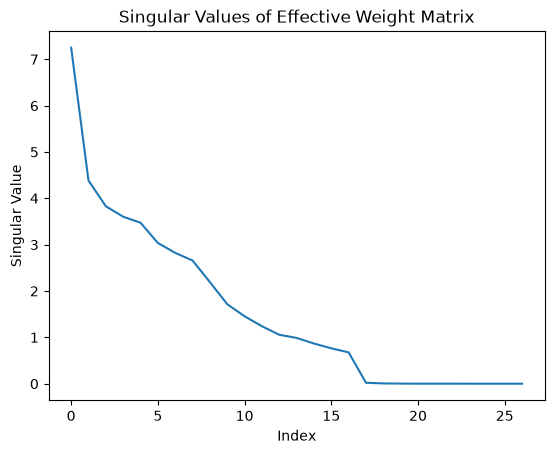

In [16]:
plt.plot(s.detach())
plt.title("Singular Values of Effective Weight Matrix")
plt.xlabel("Index")
plt.ylabel("Singular Value")
plt.show()

In [17]:
print("train loss:", split_loss("train"))
print("dev loss:", split_loss("dev"))
print("test loss:", split_loss("test"))

train loss: 2.318434238433838
dev loss: 2.3191866874694824
test loss: 2.319809913635254


In [18]:
import math
loss = split_loss("dev")
print(f'Dev Perplexity: {math.exp(loss)}')

Dev Perplexity: 10.16740166723017


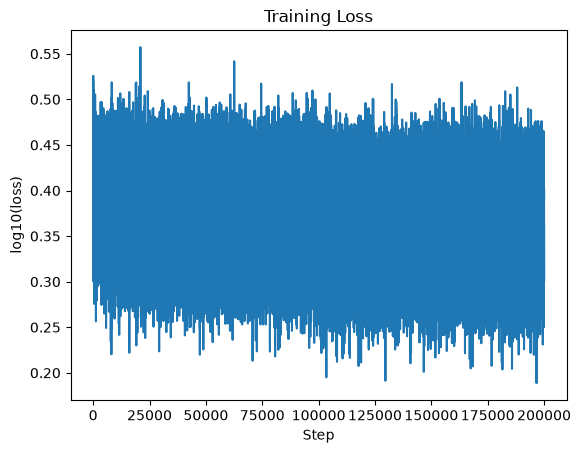

In [20]:
plt.plot(lossi)
plt.title("Training Loss")
plt.xlabel("Step")
plt.ylabel("log10(loss)")
plt.show()

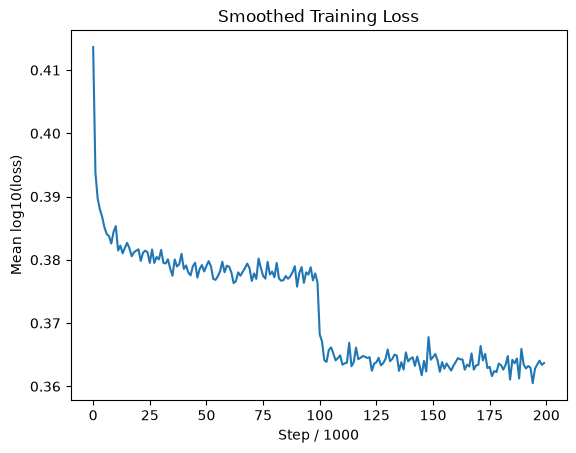

In [21]:
lossi_t = torch.tensor(lossi)

plt.plot(lossi_t.view(-1, 1000).mean(1))
plt.title("Smoothed Training Loss")
plt.xlabel("Step / 1000")
plt.ylabel("Mean log10(loss)")
plt.show()

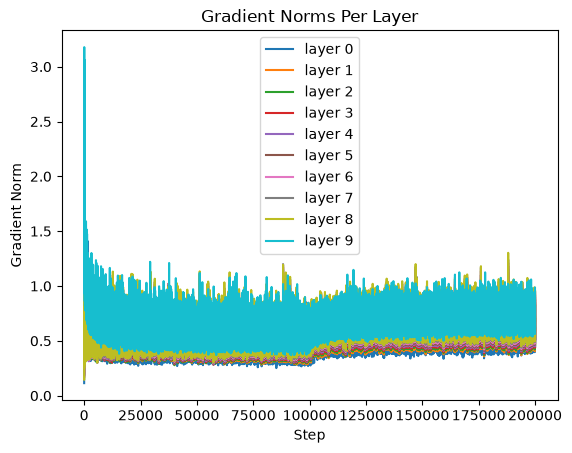

In [23]:
grad_norms_t = torch.tensor(grad_norms)

for i in range(grad_norms_t.shape[1]):
    plt.plot(grad_norms_t[:, i], label=f"layer {i}")

plt.legend()
plt.title("Gradient Norms Per Layer")
plt.xlabel("Step")
plt.ylabel("Gradient Norm")
plt.show()

## Phase 2: 1 Layer Neural Network

In [24]:
n_embd = 10 
n_hidden = 100
block_size = 3
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_embd), generator=g)
layers = [
    Linear(n_embd*block_size, vocab_size),
]

with torch.no_grad():
    # last layer make less confident
    layers[-1].weight *= 0.1
    # all other layers: apply gain
    for layer in layers[:-1]:
        if isinstance(layer, Linear):
            layer.weight *=1

parameters = [C] + [p for layer in layers for p in layer.parameters()]
num_parameters = sum(p.nelement() for p in parameters)
print(f'Num of Parameters:{num_parameters}')
for p in parameters:
    p.requires_grad=True

Num of Parameters:1107


In [25]:
max_steps = 200000
batch_size = 32
lossi = []
grad_norms = []
activation_stats = []

for i in range(max_steps):

    # Mini batch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size, ), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]

    # Forward pass
    emb = C[Xb] # Embed the characters into the vector
    x = emb.view(emb.shape[0], -1) # Concatenate the vectors

    
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, Yb)

        # Activation stats AFTER forward pass
    if i % 10000 == 0:
        step_activation_stats = []

        for li, layer in enumerate(layers):
            if isinstance(layer, Linear):
                t = layer.out.detach()

                stats = {
                    "layer": li,
                    "mean": t.mean().item(),
                    "std": t.std().item(),
                    "min": t.min().item(),
                    "max": t.max().item(),
                    "max_abs": t.abs().max().item(),
                }

                step_activation_stats.append(stats)

                print(
                    f"Layer {li}: "
                    f"mean={stats['mean']:.4f}, "
                    f"std={stats['std']:.4f}, "
                    f"min={stats['min']:.4f}, "
                    f"max={stats['max']:.4f}, "
                    f"max_abs={stats['max_abs']:.4f}"
                )

        activation_stats.append(step_activation_stats)

    # Stop if loss exploded
    if not torch.isfinite(loss):
        print(f"Loss became non-finite at step {i}: {loss.item()}")
        break
    # Backward pass
    for layer in layers:
        layer.out.retain_grad()
    for p in parameters:
        p.grad = None
    loss.backward()
    step_grad_norms = []
    for layer in layers:
        if isinstance(layer, Linear):
            step_grad_norms.append(layer.weight.grad.norm().item())
    grad_norms.append(step_grad_norms)

    # Update
    lr = 0.1 if i<100000 else 0.01 # step learning rate decay
    for p in parameters:
        p.data += -lr*p.grad

    # Track Stats
    if i%10000==0:
        print(f'{i:7d}/{max_steps:7d}:{loss.item():.4f}')
    lossi.append(loss.log10().item())


Layer 0: mean=0.0081, std=0.0956, min=-0.2705, max=0.2937, max_abs=0.2937
      0/ 200000:3.2708
Layer 0: mean=0.0027, std=1.6868, min=-4.1368, max=5.2192, max_abs=5.2192
  10000/ 200000:2.3358
Layer 0: mean=0.0066, std=1.7935, min=-4.7215, max=5.6497, max_abs=5.6497
  20000/ 200000:2.0280
Layer 0: mean=-0.0058, std=1.7292, min=-3.9367, max=5.2432, max_abs=5.2432
  30000/ 200000:2.1623
Layer 0: mean=0.0003, std=1.7706, min=-5.1662, max=4.8560, max_abs=5.1662
  40000/ 200000:2.4064
Layer 0: mean=-0.0017, std=1.8744, min=-5.4530, max=6.2234, max_abs=6.2234
  50000/ 200000:2.4310
Layer 0: mean=0.0014, std=1.9261, min=-4.8325, max=5.7942, max_abs=5.7942
  60000/ 200000:1.9749
Layer 0: mean=-0.0048, std=1.9402, min=-5.4591, max=5.3015, max_abs=5.4591
  70000/ 200000:2.2169
Layer 0: mean=-0.0025, std=1.8033, min=-4.9521, max=5.3177, max_abs=5.3177
  80000/ 200000:2.3218
Layer 0: mean=-0.0042, std=1.9887, min=-6.3116, max=5.3367, max_abs=6.3116
  90000/ 200000:2.1301
Layer 0: mean=0.0010, std

In [26]:
g = torch.Generator().manual_seed(2147483647 + 10)
for _ in range(20):
    out = []
    context = [0]* block_size

    while True:
        x_context = torch.tensor([context])
        # Forward pass the neural net
        emb = C[x_context] # Embed the characters into the vector
        x = emb.view(emb.shape[0], -1) # Concatenate the vectors
        for layer in layers:
            x = layer(x)
        logits = x
        probs = F.softmax(logits, dim=1)

        # Sample from the distribution
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()

        # Shift the sample window and track the samples
        context = context[1:]+[ix]
        out.append(ix)

        # if we sample special token ".", then break
        if ix ==0:
            break

    print("".join(itos[i] for i in out))

mria.
mmyazhieel.
ndynyal.
rethretendrlen.
adered.
eli.
jely.
jelleigin.
ananar.
kayzioh.
karin.
shubergiaghiest.
jair.
jelionn.
pona.
ubenged.
riy.
julyeh.
ylae.
musteyla.


In [27]:
print("train loss:", split_loss("train"))
print("dev loss:", split_loss("dev"))
print("test loss:", split_loss("test"))

train loss: 2.3051741123199463
dev loss: 2.3070449829101562
test loss: 2.3060920238494873


In [28]:
import math
loss = split_loss("dev")
print(f'Dev Perplexity: {math.exp(loss)}')

Dev Perplexity: 10.044698500266366


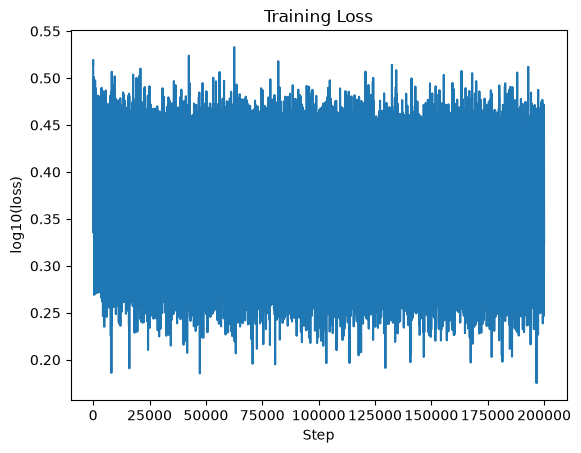

In [30]:
plt.plot(lossi)
plt.title("Training Loss")
plt.xlabel("Step")
plt.ylabel("log10(loss)")
plt.show()

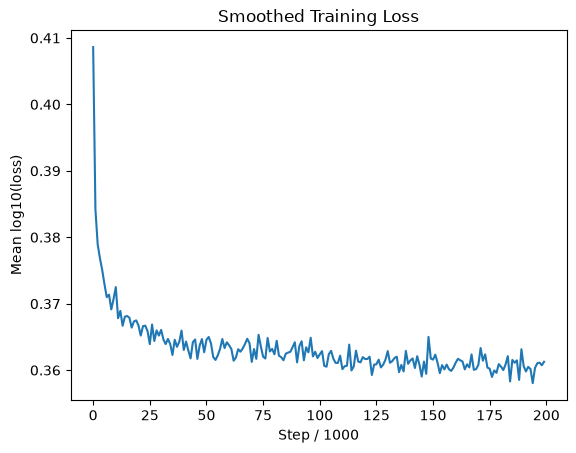

In [31]:
lossi_t = torch.tensor(lossi)

plt.plot(lossi_t.view(-1, 1000).mean(1))
plt.title("Smoothed Training Loss")
plt.xlabel("Step / 1000")
plt.ylabel("Mean log10(loss)")
plt.show()

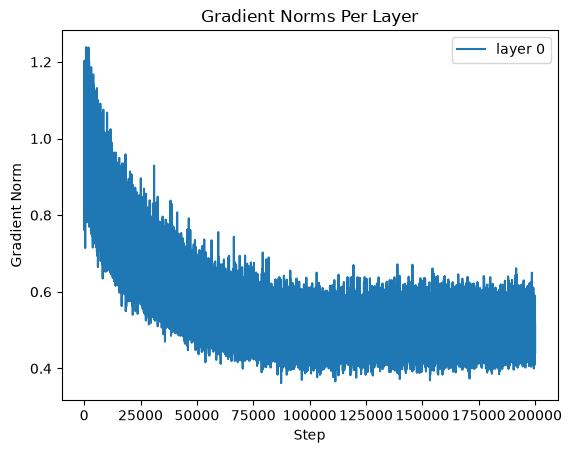

In [32]:
grad_norms_t = torch.tensor(grad_norms)

for i in range(grad_norms_t.shape[1]):
    plt.plot(grad_norms_t[:, i], label=f"layer {i}")

plt.legend()
plt.title("Gradient Norms Per Layer")
plt.xlabel("Step")
plt.ylabel("Gradient Norm")
plt.show()

## Experiment Results

| Metric                     | 1 Linear Layer |       10 Linear Layers |
| -------------------------- | -------------: | ---------------------: |
| Parameters                 |          1,107 |                 86,897 |
| Effective Function Type    |         Linear |                 Linear |
| Train Loss                 |         2.3052 |                 2.3184 |
| Dev Loss                   |         2.3070 |                 2.3192 |
| Test Loss                  |         2.3061 |                 2.3198 |
| Dev Perplexity             |        10.0447 |                10.1674 |
| Effective Rank             |            ≤27 |                     27 |
| Max Singular Value         |              — |                 7.2502 |
| Condition Number           |              — |             269592.125 |
| NaN Step                   |           None | None after fixing init |
| Expressive Power Increase? |             No |                     No |


## Conclusion

10 linear layers do not become one layer during training.
Rather, their composition is mathematically equivalent to one linear transformation.
So they add parameters and optimization complexity, but no extra expressive power unless we add nonlinearities like tanh/ReLU/BatchNorm.